# Single-bidder EDA — TED tenders & awards

Goal: understand the data before training a model that predicts whether a tender lot receives **one bid vs. more than one**.

- `data/tenders.parquet` — lot-level contract notices (features known *before* the deadline)
- `data/awards.parquet` — award notices carrying `n_tenders` (the label source)

No training here — visualization and label analysis only.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

pd.set_option('display.max_columns', 120)
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.color': '#e6e6e6',
    'grid.linewidth': 0.8,
    'axes.axisbelow': True,
    'font.size': 10,
})
# fixed palette: MULTI = blue (baseline), SINGLE = orange (the class we care about)
C_MULTI, C_SINGLE, C_NEUTRAL = '#4878b8', '#d9762b', '#9aa0a6'

tenders = pd.read_parquet('data/tenders.parquet')
awards = pd.read_parquet('data/awards.parquet')
print(f'tenders: {tenders.shape[0]:,} rows x {tenders.shape[1]} cols')
print(f'awards:  {awards.shape[0]:,} rows x {awards.shape[1]} cols')

tenders: 3,415 rows x 91 cols
awards:  1,235 rows x 40 cols


## 1. What's in each table

In [2]:
tenders.head(3)

,notice_id,notice_kind,notice_subtype,notice_version,procedure_id,lot_id,issue_date,source_file,procedure_type,accelerated,award_criterion_kind,award_criterion_types,award_criterion_weights,price_weight_pct,n_lots,contract_type,buyer_legal_type,buyer_legal_type_list,buyer_activity,buyer_activity_list,eu_funded,funding_programs,duration_days,duration_source,duration_measure_raw,duration_unit_raw,period_start,period_end,cpv_main,cpv_additional,title,description,est_value_lot,est_value_lot_currency,est_value_procedure,est_value_procedure_currency,deadline_date,deadline_days,n_selection_criteria,n_criteria_suitability,n_criteria_financial,n_criteria_technical,n_criteria_other,selection_criteria_types,selection_criteria,bid_bond_required,bid_bond_description,bid_validity_days,bid_validity_raw,bid_validity_unit,cv_required,legal_form_required,security_clearance_required,docs_restricted,docs_url,variants,multiple_bids,esubmission,place_nuts3,place_city,place_postal_zone,sme_suitable,framework_type,is_framework,procurement_additional_types,is_strategic,gpa_covered,recurring,eauction,bid_opening_date,question_deadline_date,question_window_days,opening_lag_days,is_corrigendum,changed_notice_id,change_reasons,n_corrections_so_far,buyer_name,buyer_national_id,buyer_city,buyer_postal_zone,buyer_nuts,buyer_country,buyer_website,buyer_is_cpb_awarding,buyer_is_cpb_acquiring,buyer_profile_uri,service_provider_type,platform_url,platform_name,submission_endpoint
0,087b356a-a6ce-4f98-b4da-7e055f588d19,ContractNotice,16,01,169527c9-d44c-4519-8be7-52f568a4811b,LOT-0001,2026-02-09,100152-2026.xml,open,false,price-only,[price],[100.0],NaN,1,works,la,buyer-legal-type,gen-pub,authority-activity,False,[no-eu-funds],390.0,dates,NaN,None,2027-04-12,2028-05-05,45332000,"[45332200, 45332300, 45332400]",Schulprojekt Kardinal-von-Galen-Schule - Abwas...,Schulprojekt Kardinal-von-Galen-Schule - Abwas...,485470.0,EUR,485470.0,EUR,2026-03-13,32.0,2.0,0.0,2.0,0.0,0.0,"[slc-stand-ins, slc-stand-other]","[{'type': 'slc-stand-other', 'description': 'E...",None,None,69.0,69.0,DAY,not-requ,None,None,False,http://www.deutsche-evergabe.de/dashboards/das...,not-allowed,not-allowed,required,DEA42,None,None,True,none,False,[none],False,True,False,False,2026-03-13,None,NaN,0.0,True,169527c9-d44c-4519-8be7-52f568a4811b-01,[update-add],1,Stadt Harsewinkel Zentrale Vergabestelle,6730,Harsewinkel,33428,DEA42,DEU,https://www.deutsche-evergabe.de,None,None,https://www.deutsche-evergabe.de,ted-esen,None,None,http://www.deutsche-evergabe.de/dashboards/das...
1,c2ddb6ec-0b99-45b9-bef7-be20a7c2852b,ContractNotice,16,01,1b573f5f-c587-4daa-8f93-0a4e49d50c7e,LOT-0001,2026-02-10,100452-2026.xml,open,false,None,[],[],NaN,1,works,la,buyer-legal-type,gen-pub,authority-activity,False,[no-eu-funds],NaN,None,NaN,None,None,None,45315100,[],"Gebäudemanagement, Neubau Feuerwehrtechnische ...",Netzersatzanlagen,NaN,None,NaN,None,2026-03-13,31.0,3.0,1.0,1.0,1.0,0.0,"[slc-abil-subc, slc-stand-other, slc-suit-reg-...","[{'type': 'slc-suit-reg-prof', 'description': ...",False,None,60.0,60.0,DAY,nyk,False,False,False,https://vergabe.niedersachsen.de/Satellite/not...,not-allowed,allowed,required,None,None,None,True,none,False,[none],False,False,None,False,2026-03-13,2026-03-11,29.0,0.0,False,None,[],0,Landkreis Leer,DE117262680,Leer,26789,DE94C,DEU,https://www.landkreis-leer.de/,None,None,https://www.landkreis-leer.de/Aktuelles/Aussch...,ted-esen,https://vergabe.niedersachsen.de/Satellite/not...,None,https://vergabe.niedersachsen.de/Satellite/not...
2,a66af646-f370-4f5d-b08b-9c4f141c456b,ContractNotice,16,01,7c11eacb-244b-43b1-80f4-a48be08d52b6,LOT-0001,2026-02-10,100975-2026.xml,open,false,price-only,[price],[100.0],100.0,1,works,body-pl-la,buyer-legal-type,gen-pub,authority-activity,False,[no-eu-funds],123.0,dates,NaN,None,2026-05-26,2026-09-25,45000000,[45233120],"Neubau der KA ""Untere Ahr"" in Remagen - VE11.4...",- 1.000 m³ Bodenaustausch\n- 1.260 m³ Boden ve...,1596070.5,EUR,1596070.5,EUR,2026-03

In [3]:
awards.head(3)

,notice_id,notice_subtype,notice_version,procedure_id,lot_id,lot_result_id,issue_date,source_file,buyer_name,buyer_national_id,buyer_nuts,result_code,decision_reason,award_date,n_tenders,n_tenders_esubmission,n_tenders_sme,n_tenders_micro,n_tenders_small,n_tenders_medium,n_tenders_other_eea,n_tenders_non_eea,n_tenders_inadmissible,n_tenders_abnormally_low,n_tenders_not_verified,n_participation_requests,submission_statistics,lowest_tender_amount,highest_tender_amount,n_bids_detailed,bids,winner_names,n_winners,contract_id,contract_reference,contract_title,contract_signed_date,contract_award_date,notice_total_amount,withheld_fields
0,40458df1-3206-4da4-b293-5924a27f9437,29,01,1b33380d-977d-4864-afc3-bd079cda73e9,LOT-0000,RES-0001,2026-04-24,284953-2026.xml,Stadtreinigung Hamburg AöR,001,DE600,selec-w,None,2025-02-05,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[{'code': 't-esubm', 'value': 1.0}]",NaN,NaN,1,"[{'tender_id': 'TEN-0001', 'amount': 2100601.0...",[Kreutzjans GmbH & Co.KG],1,CON-0001,VOB-OV 2024-239,Vergabeeinheit 1.1 Hoch- Tiefbau,2025-02-05,2025-02-05,2100601.0,[]
1,35da99fb-2931-4d62-b41a-39370409ac7f,29,01,588b542d-b9a1-406f-8ab0-bd680dfa37e3,LOT-0001,RES-0001,2026-04-24,291069-2026.xml,Stadt Schmallenberg,05958004004-31001-70,DEA57,selec-w,None,2000-01-01,1.0,1.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,"[{'code': 'tenders', 'value': 1.0}, {'code': '...",NaN,NaN,1,"[{'tender_id': 'TEN-0001', 'amount': None, 'cu...","[Altenbockum & Partner, Geologen]",1,CON-0001,1,"Altenbockum & Partner, Geologen, 52078 Aachen",2026-03-30,None,NaN,[not-val]
2,35da99fb-2931-4d62-b41a-39370409ac7f,29,01,588b542d-b9a1-406f-8ab0-bd680dfa37e3,LOT-0002,RES-0002,2026-04-24,291069-2026.xml,Stadt Schmallenberg,05958004004-31001-70,DEA57,selec-w,None,2000-01-01,1.0,1.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,"[{'code': 'tenders', 'value': 1.0}, {'code': '...",NaN,NaN,1,"[{'tender_id': 'TEN-0002', 'amount': None, 'cu...","[Altenbockum & Partner, Geologen]",1,CON-0001,1,"Altenbockum & Partner, Geologen, 52078 Aachen",2026-03-30,None,NaN,[not-val]


## 2. Label: number of bids per lot (`awards.n_tenders`)

`n_tenders` is only present on ~75% of award rows (the rest are mostly non-award results such as closed/no-winner notices).
Lots with **0 bids** are a separate outcome (no competition at all) — they are shown here but excluded from the binary label later.

award rows with n_tenders: 931 / 1235
zero-bid lots: 28
single-bid rate (among lots with >=1 bid): 11.4%


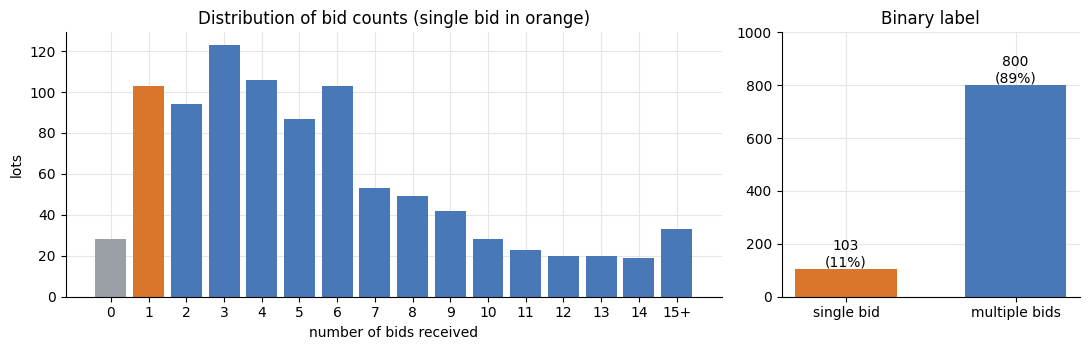

In [4]:
lab = awards[awards.n_tenders.notna()].copy()
lab['n_tenders'] = lab.n_tenders.astype(int)
print(f'award rows with n_tenders: {len(lab)} / {len(awards)}')
print(f'zero-bid lots: {(lab.n_tenders == 0).sum()}')
print(f'single-bid rate (among lots with >=1 bid): {(lab[lab.n_tenders >= 1].n_tenders == 1).mean():.1%}')

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), gridspec_kw={'width_ratios': [2.2, 1]})

h = lab.n_tenders.clip(upper=15).value_counts().sort_index()
colors = [C_NEUTRAL if k == 0 else (C_SINGLE if k == 1 else C_MULTI) for k in h.index]
axes[0].bar(h.index, h.values, color=colors, width=0.82)
axes[0].set_xticks(range(0, 16))
axes[0].set_xticklabels([*(str(i) for i in range(15)), '15+'])
axes[0].set_xlabel('number of bids received')
axes[0].set_ylabel('lots')
axes[0].set_title('Distribution of bid counts (single bid in orange)')

pos = lab[lab.n_tenders >= 1]
counts = [(pos.n_tenders == 1).sum(), (pos.n_tenders > 1).sum()]
axes[1].bar(['single bid', 'multiple bids'], counts, color=[C_SINGLE, C_MULTI], width=0.6)
for i, v in enumerate(counts):
    axes[1].text(i, v, f'{v}\n({v / len(pos):.0%})', ha='center', va='bottom')
axes[1].set_ylim(0, max(counts) * 1.25)
axes[1].set_title('Binary label')
plt.tight_layout()
plt.show()

## 3. Joining features to the label

The model's features live in `tenders` (pre-deadline information); the label lives in `awards`.
Join key: `procedure_id` + `lot_id`.

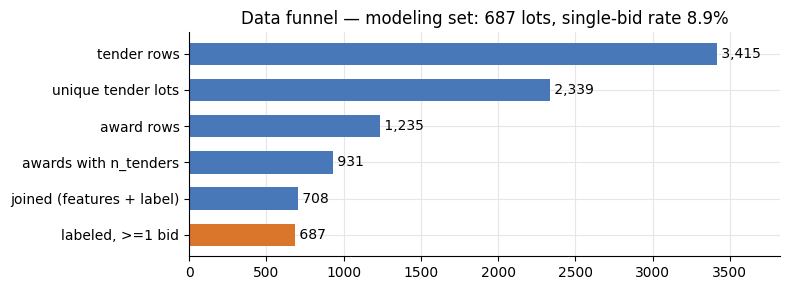

In [5]:
tenders['key'] = tenders.procedure_id.astype(str) + '|' + tenders.lot_id.astype(str)
lab['key'] = lab.procedure_id.astype(str) + '|' + lab.lot_id.astype(str)

# tenders can contain several notice versions per lot -> keep the latest per key
t_dedup = (tenders.sort_values('issue_date').drop_duplicates('key', keep='last'))

joined = lab.merge(t_dedup, on='key', how='inner', suffixes=('_award', ''))
data = joined[joined.n_tenders >= 1].copy()
data['single'] = data.n_tenders == 1

stages = [
    ('tender rows', len(tenders)),
    ('unique tender lots', tenders.key.nunique()),
    ('award rows', len(awards)),
    ('awards with n_tenders', len(lab)),
    ('joined (features + label)', len(joined)),
    ('labeled, >=1 bid', len(data)),
]
fig, ax = plt.subplots(figsize=(8, 3))
names, vals = zip(*stages)
bars = ax.barh(range(len(stages))[::-1], vals, color=[C_MULTI] * 5 + [C_SINGLE], height=0.62)
ax.set_yticks(range(len(stages))[::-1], names)
for y, v in zip(range(len(stages))[::-1], vals):
    ax.text(v, y, f' {v:,}', va='center')
ax.set_xlim(0, max(vals) * 1.12)
ax.set_title(f'Data funnel — modeling set: {len(data):,} lots, single-bid rate {data.single.mean():.1%}')
plt.tight_layout()
plt.show()

## 4. Time coverage

Both files are dominated by recent months — the earlier trickle comes from notices referenced by corrigenda/awards.

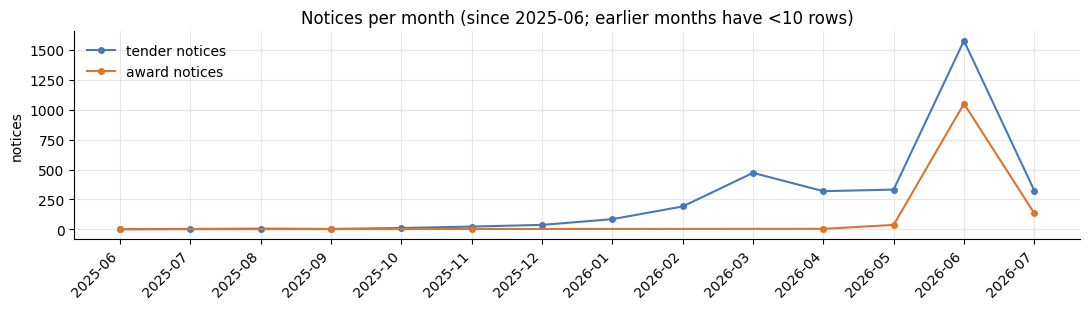

In [6]:
fig, ax = plt.subplots(figsize=(11, 3.2))
for df, color, label in [(tenders, C_MULTI, 'tender notices'), (awards, C_SINGLE, 'award notices')]:
    m = (pd.to_datetime(df.issue_date, errors='coerce', utc=True)
           .dt.tz_localize(None).dt.to_period('M').value_counts().sort_index())
    m = m[m.index >= '2025-06']
    ax.plot(m.index.astype(str), m.values, marker='o', ms=4, color=color, label=label)
ax.set_title('Notices per month (since 2025-06; earlier months have <10 rows)')
ax.set_ylabel('notices')
ax.legend(frameon=False)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. Feature completeness on the modeling set

Missingness decides which features are usable. `est_value_lot` is ~90% missing (German buyers rarely publish estimates) — effectively unusable.
`bid_bond_required`, `price_weight_pct`, `question_window_days` are ~50% missing but the missingness itself may be informative.

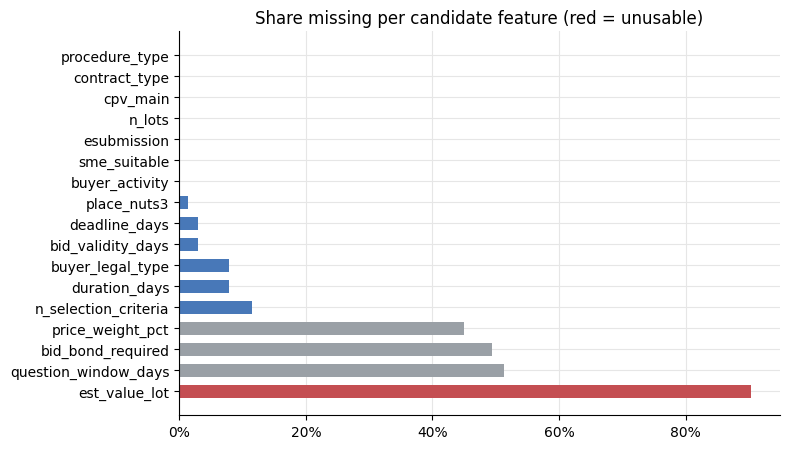

In [7]:
feats = ['procedure_type', 'contract_type', 'cpv_main', 'n_lots', 'esubmission', 'sme_suitable',
         'buyer_activity', 'place_nuts3', 'deadline_days', 'bid_validity_days', 'buyer_legal_type',
         'duration_days', 'n_selection_criteria', 'price_weight_pct', 'bid_bond_required',
         'question_window_days', 'est_value_lot']
miss = data[feats].isna().mean().sort_values()
fig, ax = plt.subplots(figsize=(8, 4.6))
colors = [C_MULTI if v <= 0.15 else (C_NEUTRAL if v <= 0.6 else '#c44e52') for v in miss.values]
ax.barh(miss.index[::-1], miss.values[::-1] * 100,
        color=colors[::-1], height=0.62)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title('Share missing per candidate feature (red = unusable)')
plt.tight_layout()
plt.show()

## 6. Single-bid rate by categorical features

Bars show the single-bid rate per category; the dashed line is the overall base rate. `n` = lots in that category.
Note the dataset is almost entirely **open-procedure construction works** (CPV 45), so procedure type and main CPV division carry no signal — the variation is *within* construction.

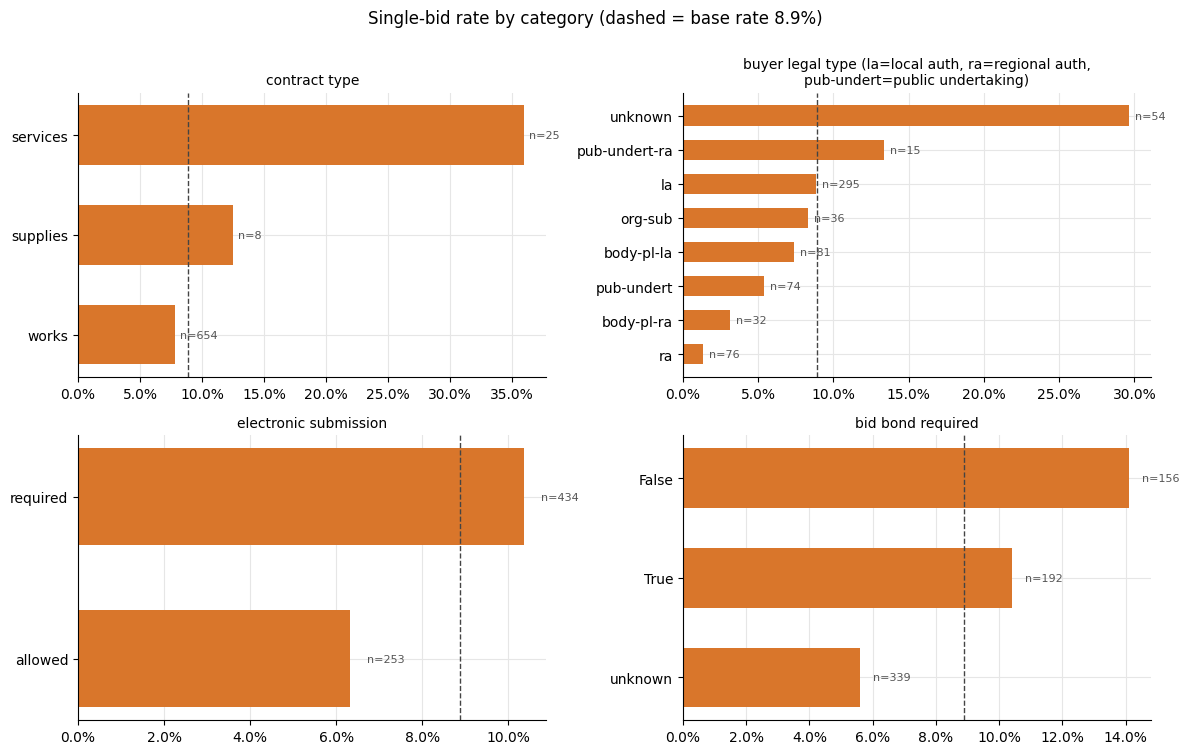

In [8]:
def rate_plot(ax, col, min_n=8, top=None, labels=None):
    g = data.groupby(data[col].astype(str).replace({'nan': 'unknown', 'None': 'unknown'}))['single'].agg(['mean', 'count'])
    g = g[g['count'] >= min_n].sort_values('mean')
    if top:
        g = g.tail(top)
    idx = list(g.index)
    ax.barh(idx, g['mean'] * 100, color=C_SINGLE, height=0.6)
    for i, (m, n) in enumerate(zip(g['mean'], g['count'])):
        ax.text(m * 100 + 0.4, i, f'n={n}', va='center', fontsize=8, color='#555')
    ax.axvline(data.single.mean() * 100, color='#444', ls='--', lw=1)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_title(labels or col, fontsize=10)

fig, axes = plt.subplots(2, 2, figsize=(12, 7.5))
rate_plot(axes[0, 0], 'contract_type', min_n=5, labels='contract type')
rate_plot(axes[0, 1], 'buyer_legal_type', min_n=15,
          labels='buyer legal type (la=local auth, ra=regional auth,\npub-undert=public undertaking)')
rate_plot(axes[1, 0], 'esubmission', labels='electronic submission')
rate_plot(axes[1, 1], 'bid_bond_required', labels='bid bond required')
fig.suptitle(f'Single-bid rate by category (dashed = base rate {data.single.mean():.1%})', y=1.0)
plt.tight_layout()
plt.show()

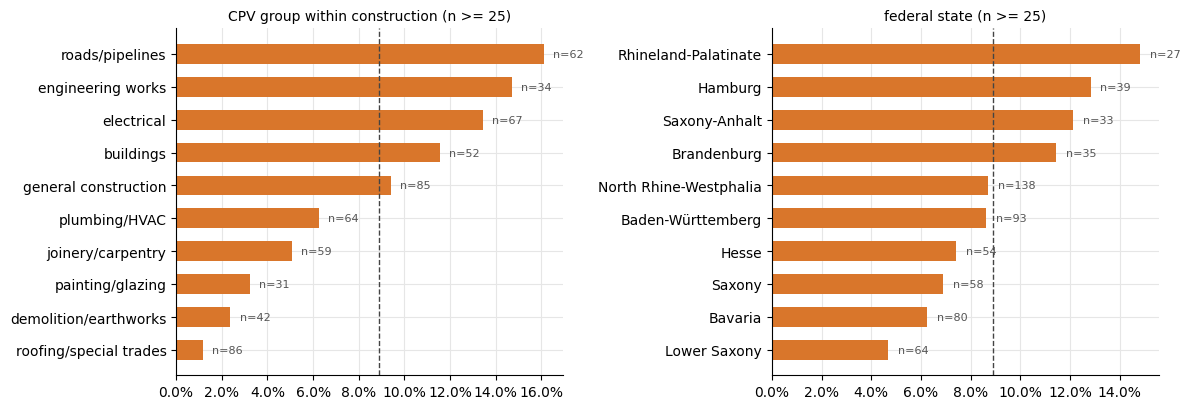

In [9]:
data['cpv4'] = data.cpv_main.astype(str).str[:4]
CPV4 = {
    '4500': 'general construction', '4511': 'demolition/earthworks', '4521': 'buildings',
    '4522': 'engineering works', '4523': 'roads/pipelines', '4526': 'roofing/special trades',
    '4531': 'electrical', '4533': 'plumbing/HVAC', '4542': 'joinery/carpentry', '4544': 'painting/glazing',
}
data['cpv4_name'] = data.cpv4.map(CPV4).fillna(data.cpv4)
data['nuts1'] = data.place_nuts3.astype(str).str[:3]
NUTS1 = {'DE1': 'Baden-Württemberg', 'DE2': 'Bavaria', 'DE4': 'Brandenburg', 'DE6': 'Hamburg',
         'DE7': 'Hesse', 'DE9': 'Lower Saxony', 'DEA': 'North Rhine-Westphalia', 'DEB': 'Rhineland-Palatinate',
         'DED': 'Saxony', 'DEE': 'Saxony-Anhalt', 'DEF': 'Schleswig-Holstein', 'DEG': 'Thuringia'}
data['region'] = data.nuts1.map(NUTS1).fillna(data.nuts1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
rate_plot(axes[0], 'cpv4_name', min_n=25, labels='CPV group within construction (n >= 25)')
rate_plot(axes[1], 'region', min_n=25, labels='federal state (n >= 25)')
plt.tight_layout()
plt.show()

## 7. Numeric features by class

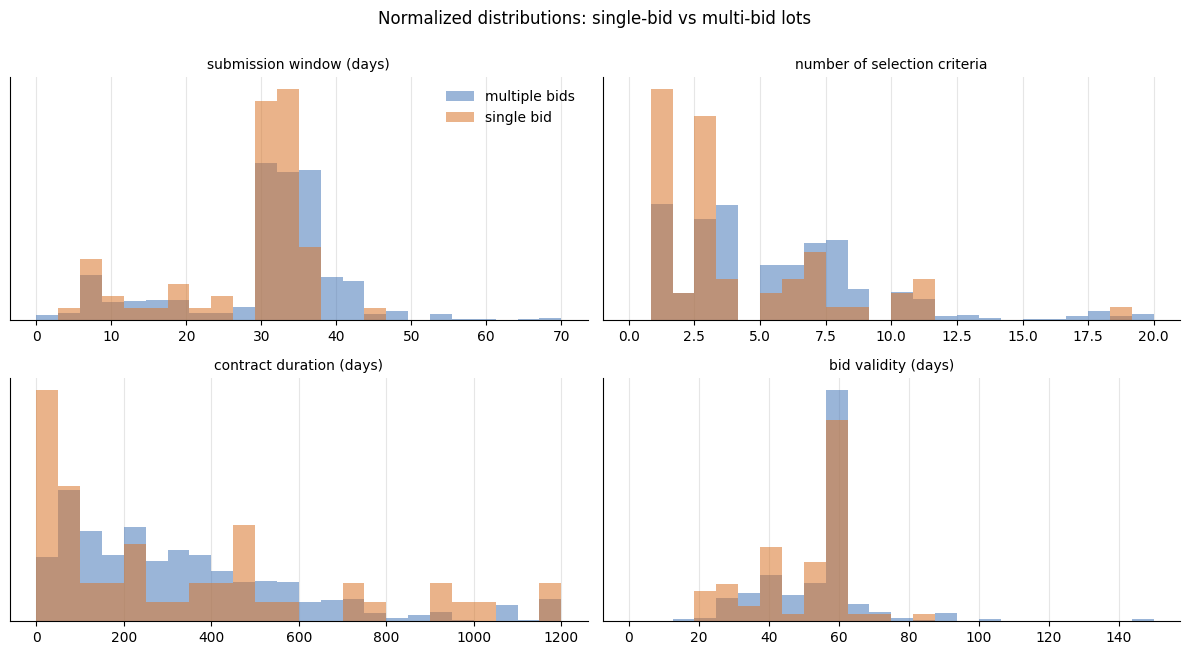

In [10]:
num_feats = [('deadline_days', 'submission window (days)', (0, 70)),
             ('n_selection_criteria', 'number of selection criteria', (0, 20)),
             ('duration_days', 'contract duration (days)', (0, 1200)),
             ('bid_validity_days', 'bid validity (days)', (0, 150))]
fig, axes = plt.subplots(2, 2, figsize=(12, 6.5))
for ax, (col, label, clip) in zip(axes.flat, num_feats):
    for mask, color, name in [(~data.single, C_MULTI, 'multiple bids'), (data.single, C_SINGLE, 'single bid')]:
        v = data.loc[mask, col].dropna().clip(*clip)
        ax.hist(v, bins=24, range=clip, density=True, alpha=0.55, color=color, label=name)
    ax.set_title(label, fontsize=10)
    ax.set_yticks([])
axes[0, 0].legend(frameon=False)
fig.suptitle('Normalized distributions: single-bid vs multi-bid lots', y=1.0)
plt.tight_layout()
plt.show()

## 8. Bidder composition (context from awards)

Not usable as model features (only known after award), but useful context on who competes.

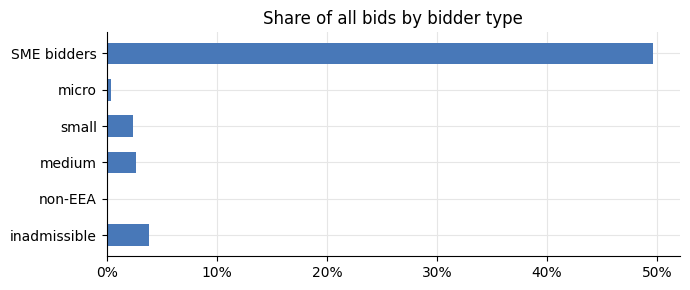

In [11]:
comp = awards[awards.n_tenders.notna() & (awards.n_tenders >= 1)]
shares = {
    'SME bidders': comp.n_tenders_sme.sum() / comp.n_tenders.sum(),
    'micro': comp.n_tenders_micro.sum() / comp.n_tenders.sum(),
    'small': comp.n_tenders_small.sum() / comp.n_tenders.sum(),
    'medium': comp.n_tenders_medium.sum() / comp.n_tenders.sum(),
    'non-EEA': comp.n_tenders_non_eea.sum() / comp.n_tenders.sum(),
    'inadmissible': comp.n_tenders_inadmissible.sum() / comp.n_tenders.sum(),
}
fig, ax = plt.subplots(figsize=(7, 3))
ks = list(shares)[::-1]
ax.barh(ks, [shares[k] * 100 for k in ks], color=C_MULTI, height=0.6)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title('Share of all bids by bidder type')
plt.tight_layout()
plt.show()

## Takeaways for modeling

1. **Modeling set is small:** ~690 labeled lots today (grows as more awards are published). The label is imbalanced: ~9% single-bid — evaluation should use PR-AUC / calibrated probabilities, not accuracy.
2. **The dataset is homogeneous by design:** almost all open-procedure construction works in Germany. `procedure_type` and the top-level CPV carry no signal; the useful variation is within construction (CPV group, trade).
3. **Promising features:** CPV group (roads/engineering ~15–16% vs special trades ~1–3%), buyer legal type (regional authorities ~1% vs unknown ~30%), contract type (rare services lots ~36%), region, number of selection criteria (fewer criteria → more single-bid), bid-bond presence/missingness.
4. **Weak/unusable:** `est_value_lot` (~90% missing), `eauction`/`is_framework` (constant), `deadline_days` (little separation), `price_weight_pct` (nearly always 100 = price-only).
5. **Leakage guard:** only `tenders` columns are features; everything in `awards` (amounts, bidder stats, winner) is post-outcome.
6. **Zero-bid lots (n=28)** are a distinct failure mode — decide whether they belong in the positive class ("insufficient competition") or get dropped.